<a href="https://colab.research.google.com/github/faizijr12github/Titanic-Logistic-Regression/blob/main/Titanic_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Project: Titanic Survival EDA + Feature Engineering + using Logistic Regression

**🗂️ Install kaggle**

In [106]:
!pip install kaggle

In [107]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [108]:
!kaggle competitions download -c titanic

titanic.zip: Skipping, found more recently modified local copy (use --force to force download)


In [109]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/titanic.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


**How my Data looks**

In [110]:
import pandas as pd
df = pd.read_csv('/content/train.csv')
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
94,95,0,3,"Coxon, Mr. Daniel",male,59.00,0,0,364500,7.2500,NaN,S
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
289,290,1,3,"Connolly, Miss. Kate",female,22.00,0,0,370373,7.7500,NaN,Q
189,190,0,3,"Turcin, Mr. Stjepan",male,36.00,0,0,349247,7.8958,NaN,S
340,341,1,2,"Navratil, Master. Edmond Roger",male,2.00,1,1,230080,26.0000,F2,S


**Checking columns**

In [111]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**How many columns and rows**

In [112]:
df.shape

(891, 12)

**Checking datatypes of columns**

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**To check statistical values**

In [114]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Are there any missing values?**

In [115]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Are there any duplicated values**

In [116]:
df.duplicated().sum()

np.int64(0)

# 📊 EDA

**🧠 Objective**

"The purpose of performing Exploratory Data Analysis (EDA) on the Titanic dataset is to uncover meaningful insights and identify key factors — such as age, gender, fare and passenger class — that influenced the survival of passengers. These insights help us select important features for building an accurate machine learning model."

**🚫 Step 4: Missing Values Heatmap**

<Axes: >

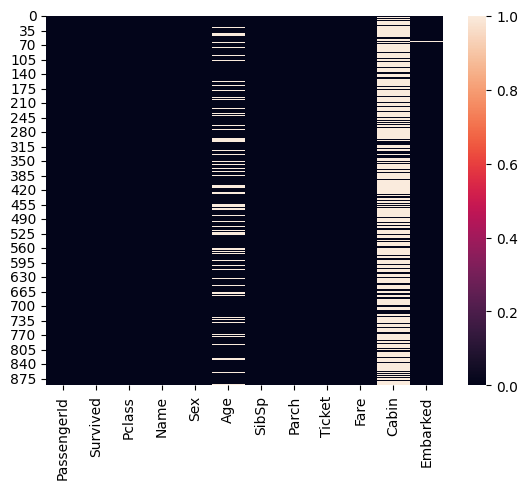

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isnull())

**🎯 Survival Distribution**

In [118]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


<Axes: xlabel='Survived', ylabel='count'>

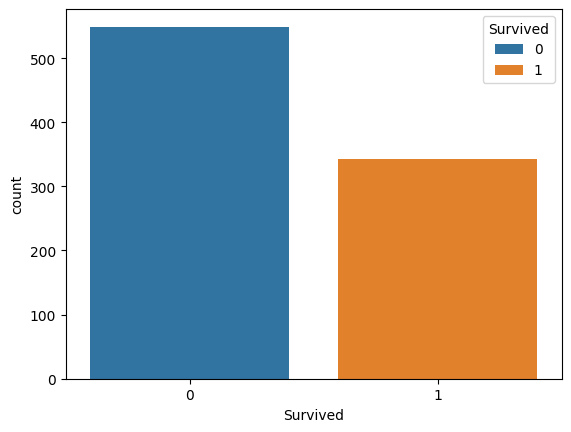

In [119]:
sns.countplot(x='Survived', data=df, hue='Survived')

**👤 Survival by Gender**

In [120]:
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

**🔍 Observations**

Total Survived: 342 👩‍🦰 Females: 233 👨‍🦱 Males: 109

Total Died: 549 👩‍🦰 Females: 81 👨‍🦱 Males: 468


<Axes: xlabel='Survived', ylabel='count'>

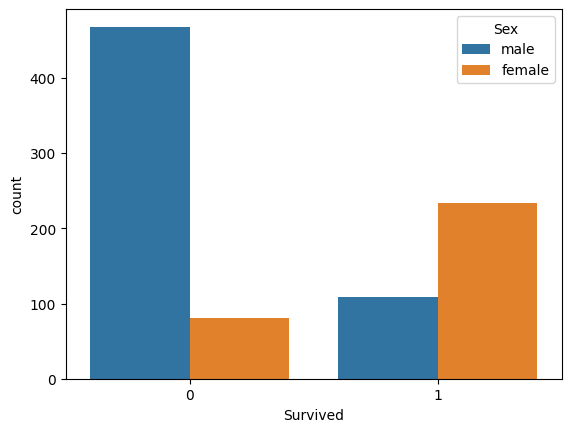

In [121]:
sns.countplot(x='Survived', data=df, hue='Sex')

**👤 Survival by Pclass**

Total People Travelling in each Pclass.

In [122]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [123]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

**🔍 Observations by Passenger Class (Pclass)**

**🎩 Pclass 1 (Upper Class):**
✅ Survived: 136 passengers

❌ Died: 80 passengers

🔎 Insight: Passengers in Pclass 1 had the highest survival rate.

**🎓 Pclass 2 (Middle Class):**
✅ Survived: 87 passengers

❌ Died: 97 passengers

🔎 Insight: Survival and death counts are almost equal, suggesting a balanced chance.

**🧳 Pclass 3 (Lower Class):**
✅ Survived: 119 passengers

❌ Died: 372 passengers

🔎 Insight: Passengers in Pclass 3 had the lowest survival rate — most deaths occurred in this class.

<Axes: xlabel='Survived', ylabel='count'>

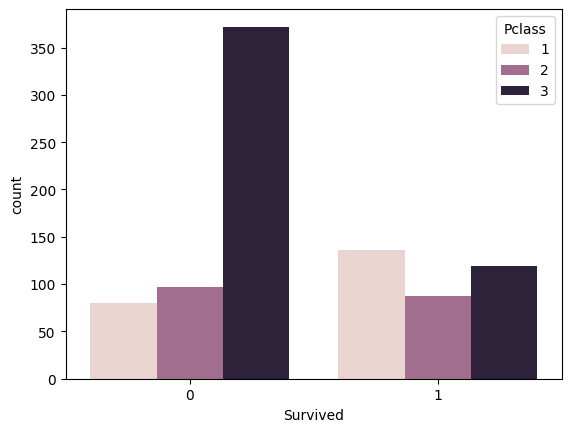

In [124]:
sns.countplot(x='Survived', data=df, hue='Pclass')

**📈 Age and Fare Distribution**

<Axes: xlabel='Age', ylabel='Density'>

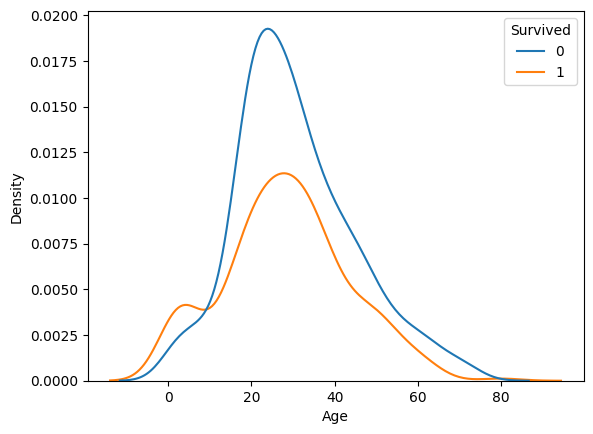

In [125]:
sns.kdeplot(data=df, x="Age", hue="Survived", fill=False)

<Axes: xlabel='Fare', ylabel='Density'>

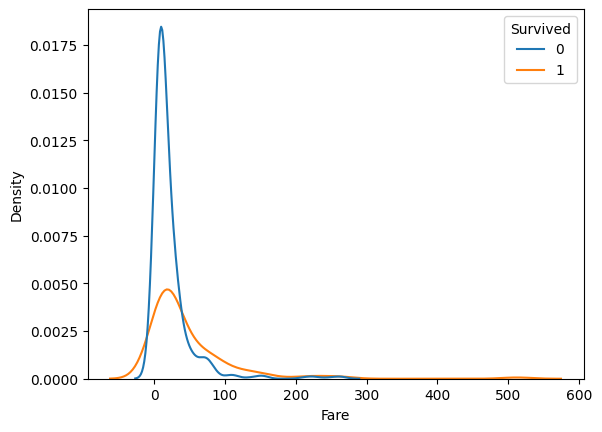

In [126]:
sns.kdeplot(data=df, x="Fare", hue="Survived", fill=False)

**📦 Boxplots:  How much Fare was given by each Pclass**

<Axes: xlabel='Pclass', ylabel='Fare'>

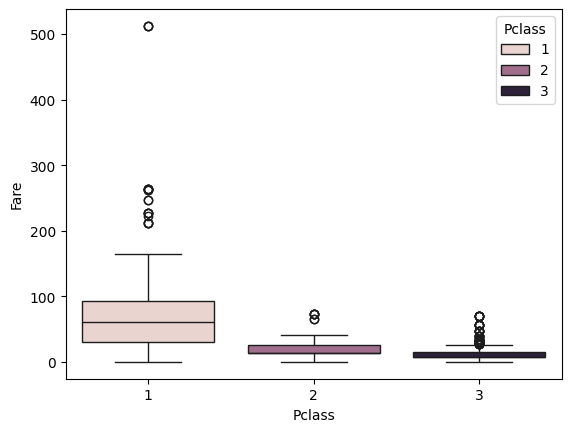

In [127]:
sns.boxplot(x='Pclass', y='Fare', data=df, hue='Pclass')

In [128]:
df.groupby("Pclass")["Fare"].mean()

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


<Axes: xlabel='Pclass', ylabel='Fare'>

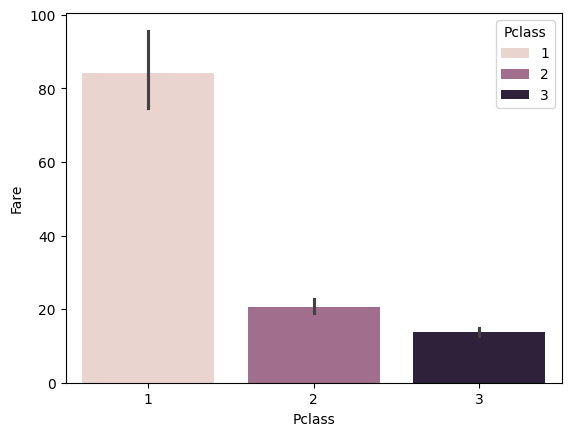

In [129]:
sns.barplot(data=df, x='Pclass',y='Fare',hue='Pclass')

This shows the survival of passengers across different Pclasses and age groups.

<Axes: xlabel='Survived', ylabel='Age'>

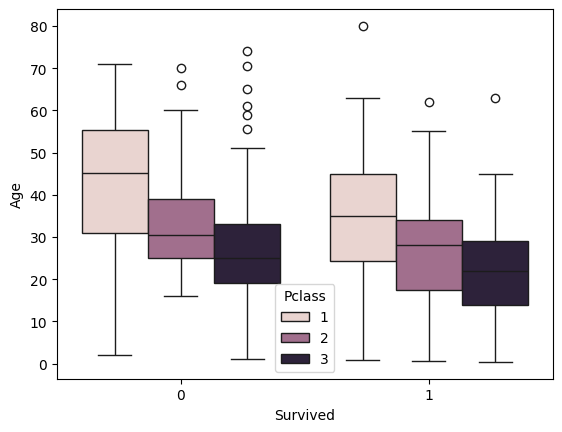

In [130]:
sns.boxplot(x='Survived', y='Age', data=df, hue='Pclass')

**🛳️ Survival by Port of Embarkation**

<Axes: xlabel='Embarked', ylabel='count'>

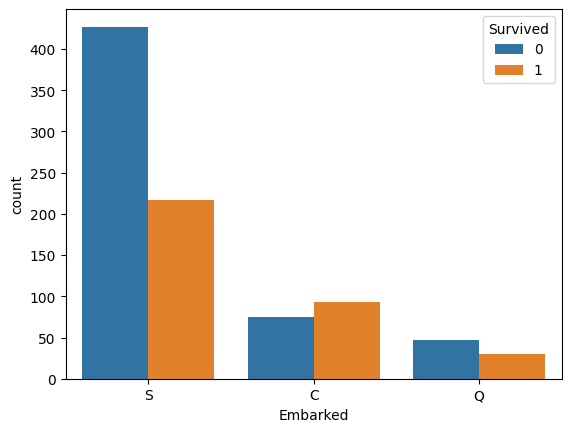

In [131]:
sns.countplot(x='Embarked', hue='Survived', data=df)

**🛳️ Survival by SibSp**

<Axes: xlabel='SibSp', ylabel='count'>

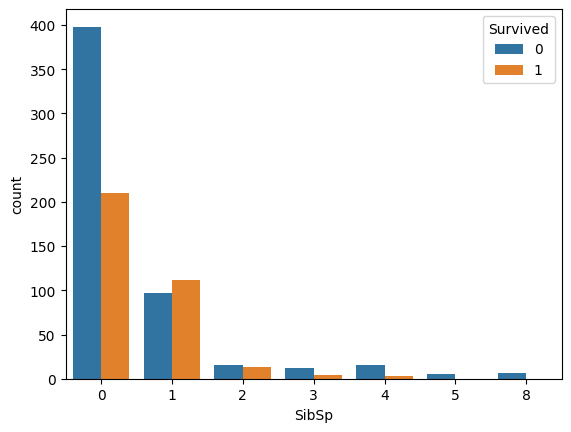

In [132]:
sns.countplot(x='SibSp',data=df,hue='Survived')

**🛳️ Survival by Parch**

<Axes: xlabel='Parch', ylabel='count'>

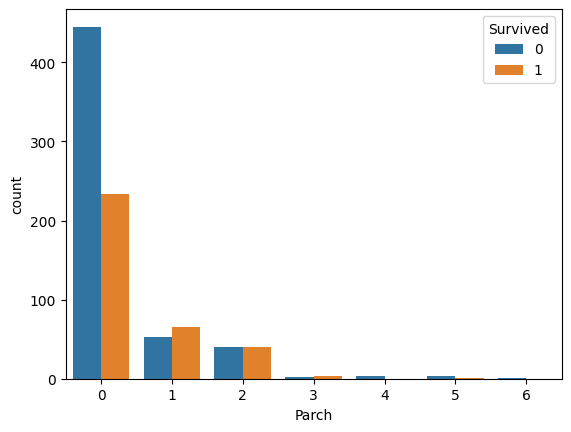

In [133]:
sns.countplot(x='Parch',data=df,hue='Survived')

# 🔧 Feature Engineering

**❌ Dropping Columns**

**❌ PassengerId**

🔢 Just a unique number for each person.

✅ It's like a serial number. It has no connection to survival.

**❌ Name**

📛 Names are text and don’t help with prediction.

💡 Sometimes you can extract a title (Mr, Mrs, etc.) from the name — that could help!

But the full name itself is too specific and random.

**❌ Ticket**

🎫 It's a ticket number, like A/5 21171 or 113803.

These are random codes, not useful by themselves.

💡 Unless you extract patterns (like same ticket group → family), it's better to remove.

**❌ Cabin**

🛏️ Cabin numbers are missing for many people.

And they are also text like C85, E46 → not very useful directly.

Too much missing data, so we drop it.



In [134]:
df = df.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [135]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
774,1,2,female,54.0,1,3,23.0000,S
77,0,3,male,NaN,0,0,8.0500,S
558,1,1,female,39.0,1,1,79.6500,S
32,1,3,female,NaN,0,0,7.7500,Q
653,1,3,female,NaN,0,0,7.8292,Q


**🧼 Data Cleaning - Handling Missing Values**

In [136]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


<ipython-input-137-faeb809739be>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'],kde=True,hist=False)


<Axes: xlabel='Age', ylabel='Density'>

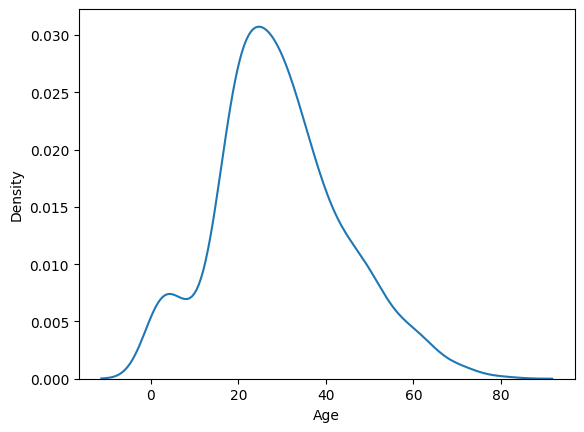

In [137]:
sns.distplot(df['Age'],kde=True,hist=False)

Removing outliers from age before imputing it

In [138]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

# Calculate the IQR
IQR = Q3 - Q1

# Define the outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip the Age column to remove outliers
df['Age'] = df['Age'].clip(lower=lower_bound, upper=upper_bound)

✅ Best Approach for Positively Skewed Data:

🔍 Use the median to fill missing values.

In [139]:
from sklearn.impute import SimpleImputer

# Step 1: Create the imputer
imputer = SimpleImputer(strategy='median')

# Step 2: Fit and transform the 'Age' column
df['Age'] = imputer.fit_transform(df[['Age']])

In [140]:
df['Age'].isnull().sum()

np.int64(0)

✅ Best Approach: Embarked has categorical missing values only 2

🔍 Fill missing values with the most frequent (mode) value

In [141]:
df['Embarked'].isnull().sum()

np.int64(2)

In [142]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df['Embarked'] = cat_imputer.fit_transform(df[['Embarked']])[:,0]

In [143]:
df['Embarked'].isnull().sum()

np.int64(0)

**📘 Encoding Categorical Variables**

Apply One-Hot Encoding on Sex column

In [144]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)  # Drop one to avoid duplicate info | sparse_output=False => Returns normal 2D NumPy array (easy to use)
df['Sex'] = encoder.fit_transform(df[['Sex']])[:, 0].astype(int)

Apply One-Hot Encoding on Embarked column

In [145]:
# Fit and transform the Embarked column
encoded_embarked = encoder.fit_transform(df[['Embarked']])

# Convert encoded output into a DataFrame
encoded_df = pd.DataFrame(encoded_embarked, columns=encoder.get_feature_names_out(['Embarked'])).astype(int)

# Reset index to align properly with original df
encoded_df.index = df.index

# Drop the original 'Embarked' column and concatenate new one
df = pd.concat([df.drop('Embarked', axis=1), encoded_df], axis=1)

In [146]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
670,1,2,0,40.0,1,1,39.0000,0,1
882,0,3,0,22.0,0,0,10.5167,0,1
487,0,1,1,58.0,0,0,29.7000,0,0
387,1,2,0,36.0,0,0,13.0000,0,1
3,1,1,0,35.0,1,0,53.1000,0,1


Applying ordinal encoding to the Pclass

This will encode:

Pclass 1 → 0

Pclass 2 → 1

Pclass 3 → 2

In [147]:
from sklearn.preprocessing import OrdinalEncoder

# Initialize the encoder
ordinal_encoder = OrdinalEncoder()

# Fit and transform the Pclass column
df['Pclass_encoded'] = ordinal_encoder.fit_transform(df[['Pclass']]).astype(int)

# Optional: Drop the original Pclass column if you only want the encoded one
df.drop('Pclass', axis=1, inplace=True)

In [148]:
df.sample(5)

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Pclass_encoded
348,1,1,3.0000,1,1,15.9000,0,1,2
680,0,0,28.0000,0,0,8.1375,1,0,2
727,1,0,28.0000,0,0,7.7375,1,0,2
630,1,1,64.8125,0,0,30.0000,0,1,0
422,0,1,29.0000,0,0,7.8750,0,1,2


Feature Construction

In [149]:
# Create a 'Family' column by summing Parch and SibSp
df['Family'] = df['Parch'] + df['SibSp']

# Convert Family into binary: 1 if has family, 0 if alone
df['Family'] = (df['Family'] > 0).astype(int)

# Optional: Drop Parch and SibSp if no longer needed
df.drop(['Parch', 'SibSp'], axis=1, inplace=True)

In [150]:
df.sample(5)

,Survived,Sex,Age,Fare,Embarked_Q,Embarked_S,Pclass_encoded,Family
103,0,1,33.0,8.6542,0,1,2,0
794,0,1,25.0,7.8958,0,1,2,0
495,0,1,28.0,14.4583,0,0,2,0
772,0,0,57.0,10.5000,0,1,1,0
691,1,0,4.0,13.4167,0,0,2,1


In [151]:
df.shape

(891, 8)

<Axes: xlabel='Fare', ylabel='Density'>

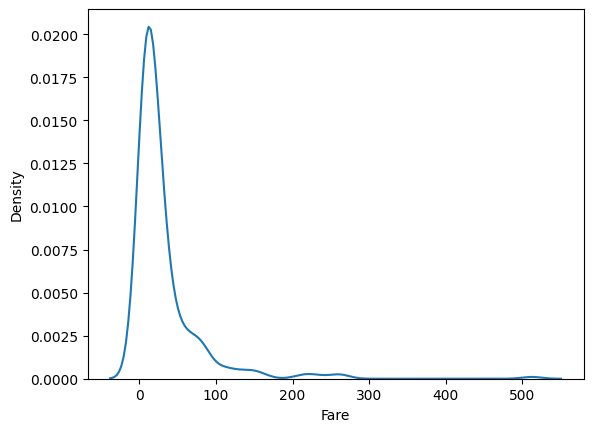

In [152]:
sns.kdeplot(df['Fare'])

<Axes: xlabel='Fare'>

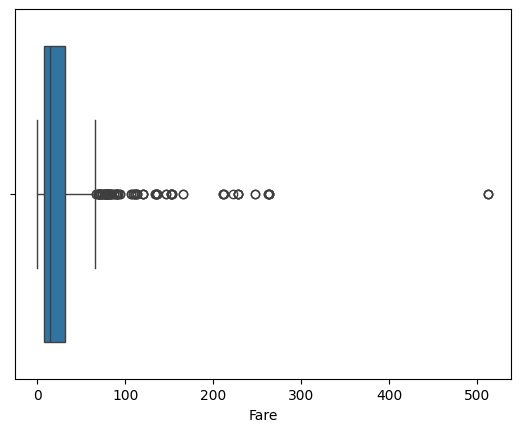

In [153]:
sns.boxplot(data=df, x='Fare')

In [154]:
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)

# Calculate the IQR for Fare
IQR_fare = Q3_fare - Q1_fare

# Define the outlier boundaries for Fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

# Clip the Fare column to remove outliers
df['Fare'] = df['Fare'].clip(lower=lower_bound_fare, upper=upper_bound_fare)

In [155]:
# Step 1: Create the imputer
imputer = SimpleImputer(strategy='median')

# Step 2: Fit and transform the 'Fare' column
df['Fare'] = imputer.fit_transform(df[['Fare']])

In [156]:
df.shape

(891, 8)

In [157]:
df.sample(5)

,Survived,Sex,Age,Fare,Embarked_Q,Embarked_S,Pclass_encoded,Family
529,0,1,23.0,11.50,0,1,1,1
880,1,0,25.0,26.00,0,1,1,1
749,0,1,31.0,7.75,1,0,2,0
589,0,1,28.0,8.05,0,1,2,0
259,1,0,50.0,26.00,0,1,1,1


In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
columns_to_scale = ['Age', 'Fare']  # Only continuous features

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [159]:
df.sample(5)

,Survived,Sex,Age,Fare,Embarked_Q,Embarked_S,Pclass_encoded,Family
801,1,0,0.132544,0.107629,0,1,1,1
430,1,1,-0.101404,0.122285,0,1,0,0
827,1,1,-2.206936,0.632990,0,0,1,1
251,0,0,-0.023422,-0.663616,0,1,2,1
82,1,0,-0.101404,-0.794295,1,0,2,0


In [160]:
df.shape

(891, 8)

**📚 Train-Test Split**

In [161]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=10)

**🤖 Model Training - Logistic Regression**

In [166]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**📊 Model Evaluation**

In [167]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.835820895522388
